## RAW DATA PROCESSING AND MERGING

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
index_csv_file='../data/raw/index.csv'
index_df=pd.read_csv(index_csv_file,index_col=False)

surface_csv_file='../data/raw/surface.csv'
surface_df=pd.read_csv(surface_csv_file,index_col=False)

In [60]:
index_df

,YEAR,MONTH,DAY,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
0,1981,1,1,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636
1,1981,1,2,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592
2,1981,1,4,128.3,6.9,6.9,17.5,16.3,25.3,41.6,284.79,978.71,0.0,0.0,23.8,5581
3,1981,1,5,194.2,2.8,1.2,23.5,22.5,28.1,50.6,286.68,965.77,-138.5,83.1,28.6,5578
4,1981,1,6,151.4,5.1,1.8,25.4,18.9,24.9,43.8,289.11,975.72,-112.9,47.9,33.2,5648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11878,2020,12,27,75.7,17.1,17.2,-19.9,-24.3,21.8,-2.5,279.17,876.91,0.0,0.0,9.5,5731
11879,2020,12,28,67.9,15.9,15.5,-6.5,-21.5,20.4,-1.1,280.77,893.60,0.0,0.0,11.4,5718
11880,2020,12,29,98.9,16.2,16.1,-15.2,5.3,18.1,23.4,278.86,862.08,0.0,0.0,13.4,5717
11881,2020,12,30,135.8,13.4,12.2,-6.5,11.4,18.1,29.5,282.07,892.90,0.0,0.0,16.2,5715


In [61]:
surface_df

,YEAR,MONTH,DAY,TH
0,1981,1,1,0
1,1981,1,2,0
2,1981,1,3,0
3,1981,1,4,0
4,1981,1,5,0
...,...,...,...,...
14392,2020,12,27,0
14393,2020,12,28,0
14394,2020,12,29,0
14395,2020,12,30,0


count the number of TH 

In [62]:
th_counts=surface_df['TH'].value_counts()
print(th_counts)

TH
0    11624
1     2772
         1
Name: count, dtype: int64


### MERGING

In [63]:
index_df.describe()

,YEAR,MONTH,DAY,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
count,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000
mean,1998.286712,6.539510,15.728099,182.923858,6.931743,0.521754,23.206581,15.603484,24.329142,39.932626,292.705253,952.021543,-63.671472,900.712421,40.506825,5750.025162
std,11.154318,3.433968,8.819977,92.033776,4.465433,7.002176,15.823667,7.171165,4.109635,9.294096,6.189168,39.226386,404.003436,1332.376203,17.504832,70.235229
min,1981.000000,1.000000,1.000000,5.800000,-9.600000,-21.700000,-62.300000,-36.700000,8.900000,-17.900000,254.750000,497.250000,-29338.900000,0.000000,-24.400000,5530.000000
25%,1989.000000,4.000000,8.000000,104.600000,4.100000,-4.300000,11.400000,11.900000,21.700000,35.400000,288.035000,935.950000,-79.700000,0.000000,25.400000,5699.000000
50%,1997.000000,7.000000,16.000000,185.300000,6.600000,-1.400000,28.200000,17.700000,23.700000,41.800000,294.790000,961.010000,-12.900000,87.800000,38.600000,5757.000000
75%,2005.500000,10.000000,23.000000,249.050000,9.400000,4.600000,35.800000,20.700000,26.800000,45.800000,297.760000,979.870000,0.000000,1544.150000,55.400000,5806.000000
max,2020.000000,12.000000,31.000000,850.700000,44.100000,27.800000,62.100000,33.300000,40.700000,69.800000,310.810000,1168.110000,29.000000,16555.900000,98.900000,5961.000000


In [64]:
surface_df.describe()

,YEAR,MONTH,DAY
count,14397.000000,14397.000000,14397.000000
mean,2000.326179,6.517052,15.727026
std,11.426269,3.452945,8.800485
min,1981.000000,1.000000,1.000000
25%,1990.000000,4.000000,8.000000
50%,2000.000000,7.000000,16.000000
75%,2010.000000,10.000000,23.000000
max,2020.000000,12.000000,31.000000


convert all dats columns into date time format

In [65]:
index_df['Date']=pd.to_datetime(index_df[['YEAR','MONTH','DAY']]).dt.strftime('%d/%m/%y')
surface_df['Date']=pd.to_datetime(surface_df[['YEAR','MONTH','DAY']]).dt.strftime('%d/%m/%y')

In [66]:
surface_df

,YEAR,MONTH,DAY,TH,Date
0,1981,1,1,0,01/01/81
1,1981,1,2,0,02/01/81
2,1981,1,3,0,03/01/81
3,1981,1,4,0,04/01/81
4,1981,1,5,0,05/01/81
...,...,...,...,...,...
14392,2020,12,27,0,27/12/20
14393,2020,12,28,0,28/12/20
14394,2020,12,29,0,29/12/20
14395,2020,12,30,0,30/12/20


INNER JOIN

drop some cols

In [67]:
columns_to_drop=['DAY','MONTH','YEAR']
surface_df.drop(columns=columns_to_drop,inplace=True)
index_df.drop(columns=columns_to_drop,inplace=True)

merge

In [68]:
merged_df=pd.merge(index_df,surface_df,on='Date',how='inner')
merged_df.to_csv('../data/raw/merged_df_all12.csv',index=False)

## COMBINING DATA

In [69]:
merged_df=pd.read_csv('../data/raw/merged_df_all12.csv')
print(merged_df.head())

   SWEAT index  Showalter index  LIFTED index  ...  1000-500 THICKNESS      Date  TH
0         91.2             12.4          13.4  ...                5636  01/01/81   0
1         75.7             10.2          11.3  ...                5592  02/01/81   0
2        128.3              6.9           6.9  ...                5581  04/01/81   0
3        194.2              2.8           1.2  ...                5578  05/01/81   0
4        151.4              5.1           1.8  ...                5648  06/01/81   0

[5 rows x 15 columns]


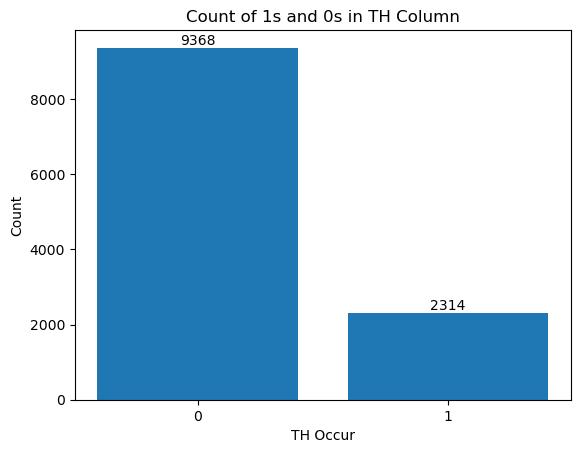

In [70]:
th_counts=merged_df['TH'].value_counts()
plt.bar(th_counts.index,th_counts.values)

plt.xlabel("TH Occur")
plt.ylabel("Count")
plt.title("Count of 1s and 0s in TH Column")

plt.xticks([0,1],['0','1'])

for i,count in enumerate(th_counts.values):
    plt.text(i,count,str(count),ha='center',va='bottom')

plt.show()

COMBINING

In [71]:
merged_df['Environmental_Stability']=merged_df['Showalter index']+merged_df['LIFTED index']
merged_df['Moisture_Indices']=merged_df['PRECIPITABLE WATER']
merged_df['Convective_Potential']=merged_df['CAPE']+merged_df['CINE']
merged_df['Temperature_Pressure']=merged_df['1000-500 THICKNESS']
merged_df['Moisture_Temperature_Profiles']=merged_df['PLCL']

In [72]:
merged_df.drop(['Showalter index','LIFTED index','PRECIPITABLE WATER','Cross totals index','Vertical totals index','CAPE','CINE','1000-500 THICKNESS','TLCL','PLCL'],axis=1,inplace=True)

In [73]:
merged_df

,SWEAT index,K index,Totals totals index,Date,TH,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles
0,91.2,-1.4,24.7,01/01/81,0,25.8,22.8,0.0,5636,993.98
1,75.7,1.6,30.3,02/01/81,0,21.5,20.4,0.0,5592,956.13
2,128.3,17.5,41.6,04/01/81,0,13.8,23.8,0.0,5581,978.71
3,194.2,23.5,50.6,05/01/81,0,4.0,28.6,-55.4,5578,965.77
4,151.4,25.4,43.8,06/01/81,0,6.9,33.2,-65.0,5648,975.72
...,...,...,...,...,...,...,...,...,...,...
11677,75.7,-19.9,-2.5,27/12/20,0,34.3,9.5,0.0,5731,876.91
11678,67.9,-6.5,-1.1,28/12/20,0,31.4,11.4,0.0,5718,893.60
11679,98.9,-15.2,23.4,29/12/20,0,32.3,13.4,0.0,5717,862.08
11680,135.8,-6.5,29.5,30/12/20,0,25.6,16.2,0.0,5715,892.90


Data is ready

In [74]:
columns=list(merged_df.columns)

columns.remove('TH')
columns.append('TH')

merged_df=merged_df[columns]

In [75]:
merged_df

,SWEAT index,K index,Totals totals index,Date,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles,TH
0,91.2,-1.4,24.7,01/01/81,25.8,22.8,0.0,5636,993.98,0
1,75.7,1.6,30.3,02/01/81,21.5,20.4,0.0,5592,956.13,0
2,128.3,17.5,41.6,04/01/81,13.8,23.8,0.0,5581,978.71,0
3,194.2,23.5,50.6,05/01/81,4.0,28.6,-55.4,5578,965.77,0
4,151.4,25.4,43.8,06/01/81,6.9,33.2,-65.0,5648,975.72,0
...,...,...,...,...,...,...,...,...,...,...
11677,75.7,-19.9,-2.5,27/12/20,34.3,9.5,0.0,5731,876.91,0
11678,67.9,-6.5,-1.1,28/12/20,31.4,11.4,0.0,5718,893.60,0
11679,98.9,-15.2,23.4,29/12/20,32.3,13.4,0.0,5717,862.08,0
11680,135.8,-6.5,29.5,30/12/20,25.6,16.2,0.0,5715,892.90,0


In [76]:
merged_df.to_csv('../data/processed/merged_df_all12k_combined.csv',index=False)

## MODEL TRAINING

import combined data

In [77]:
merge_df=pd.read_csv('../data/processed/merged_df_all12k_combined.csv')

print(merged_df.head())

   SWEAT index  K index  ...  Moisture_Temperature_Profiles TH
0         91.2     -1.4  ...                         993.98  0
1         75.7      1.6  ...                         956.13  0
2        128.3     17.5  ...                         978.71  0
3        194.2     23.5  ...                         965.77  0
4        151.4     25.4  ...                         975.72  0

[5 rows x 10 columns]


In [78]:
merged_df=merged_df.drop(['Date'],axis=1)

In [79]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

x=merged_df[['SWEAT index', 'K index', 'Totals totals index', 'Environmental_Stability',
            'Moisture_Indices', 'Convective_Potential', 'Temperature_Pressure',
            'Moisture_Temperature_Profiles']]
y=merged_df['TH']

smote=SMOTE()
x_resampled,y_resampled=smote.fit_resample(x,y)

x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2,random_state=42)

model=RandomForestClassifier()

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

HOW DID OUR MODEL PERFORM

In [80]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)

total_positive=cm[1].sum()
total_negative=cm[0].sum()
true_positives=cm[1][1]
false_positives=cm[0][1]
false_negatives=cm[1][0]
true_negatives=cm[0][0]

pod=true_positives/total_positive
far=false_positives/total_negative

hss=2 * ((true_positives * true_negatives) - (false_positives * false_negatives)) / (
        (true_positives + false_negatives) * (false_positives + true_negatives) +
        (true_positives + false_positives) * (false_negatives + true_negatives))
csi=true_positives/(true_positives+false_positives+false_negatives)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)
print("="*40)
print("Probability of Detection (POD):",pod)
print("False Alarm Rate (FAR):",far)
print("Heidke Skill Score (HSS):",hss)
print("Critical Sucess Index (CSI):",csi)

Accuracy: 0.8145677694770544
Precision: 0.7634311512415349
Recall: 0.9081632653061225
F1-score: 0.8295315182732401
Probability of Detection (POD): 0.9081632653061225
False Alarm Rate (FAR): 0.27783669141039236
Heidke Skill Score (HSS): 0.6409246297446176
Critical Sucess Index (CSI): 0.7087175188600168


PRINT CONFUSION MATRIX

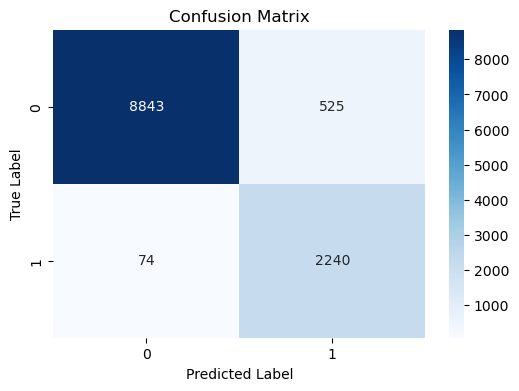

In [81]:
predictions=model.predict(x)

predictions=np.where(predictions.flatten()>0.6,1,0)

result_df=pd.DataFrame(data=x,columns=x.columns)
result_df['True Label']=y
result_df['Predicted Label']=predictions

true_labels=result_df['True Label']
predicted_labels=result_df['Predicted Label']

confusion_mat=confusion_matrix(true_labels,predicted_labels)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_mat,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel('True Label')
plt.title("Confusion Matrix")

plt.show()

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [83]:
X = merged_df[['SWEAT index', 'K index', 'Totals totals index',
               'Environmental_Stability', 'Moisture_Indices',
               'Convective_Potential', 'Temperature_Pressure',
               'Moisture_Temperature_Profiles']]

y = merged_df['TH']

In [84]:
smote=SMOTE(random_state=42)
x_resampled,y_resampled=smote.fit_resample(x,y)

x_train,x_test,y_train,y_test=train_test_split(
    x_resampled,y_resampled,test_size=0.2,random_state=42
)

In [85]:
models={
    'Logistic Regression':LogisticRegression(max_iter=1000),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'SVM':SVC(),
    'KNN':KNeighborsClassifier(),
    'Navie Bayes':GaussianNB()
}

In [86]:
result=[]

for model_name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)

    total_positive=cm[1].sum()
    total_negative=cm[0].sum()
    true_positives=cm[1][1]
    false_positives=cm[0][1]
    false_negatives=cm[1][0]
    true_negatives=cm[0][0]

    pod=true_positives/total_positive
    far=false_positives/total_negative

    hss=2 * ((true_positives * true_negatives) - (false_positives * false_negatives)) / (
        (true_positives + false_negatives) * (false_positives + true_negatives) +
        (true_positives + false_positives) * (false_negatives + true_negatives))
    csi=true_positives/(true_positives+false_positives+false_negatives)

    result.append([model_name,accuracy,precision,recall,f1,pod,far,hss,csi])

    print("="*60)
    print(f"Model : {model_name}")
    print("Accuracy:",accuracy)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1-score:",f1)
    print("Probability of Detection (POD):",pod)
    print("False Alarm Rate (FAR):",far)
    print("Heidke Skill Score (HSS):",hss)
    print("Critical Sucess Index (CSI):",csi)
    

Model : Logistic Regression
Accuracy: 0.7123799359658485
Precision: 0.677536231884058
Recall: 0.80343716433942
F1-score: 0.7351351351351352
Probability of Detection (POD): 0.80343716433942
False Alarm Rate (FAR): 0.37751855779427357
Heidke Skill Score (HSS): 0.4327837811405354
Critical Sucess Index (CSI): 0.5811965811965812
Model : Decision Tree
Accuracy: 0.7382604055496265
Precision: 0.7276485788113695
Recall: 0.7561761546723953
F1-score: 0.741638135370029
Probability of Detection (POD): 0.7561761546723953
False Alarm Rate (FAR): 0.27942735949098624
Heidke Skill Score (HSS): 0.4769917236559506
Critical Sucess Index (CSI): 0.5893679363750524
Model : Random Forest
Accuracy: 0.816435432230523
Precision: 0.7663339382940109
Recall: 0.9070891514500538
F1-score: 0.8307919331037875
Probability of Detection (POD): 0.9070891514500538
False Alarm Rate (FAR): 0.2730646871686108
Heidke Skill Score (HSS): 0.6439965360793254
Critical Sucess Index (CSI): 0.7105595288178376
Model : SVM
Accuracy: 0.709

In [87]:
result_df=pd.DataFrame(result,columns=[
    'Model','Accuracy','Precision','Recall','F1-Score',
    'POD','FAR','HSS','CSI'
])
print('\n Final Comparison Table:\n')
print(result_df)


 Final Comparison Table:

                 Model  Accuracy  Precision  ...       FAR       HSS       CSI
0  Logistic Regression  0.712380   0.677536  ...  0.377519  0.432784  0.581197
1        Decision Tree  0.738260   0.727649  ...  0.279427  0.476992  0.589368
2        Random Forest  0.816435   0.766334  ...  0.273065  0.643997  0.710560
3                  SVM  0.709178   0.658067  ...  0.442736  0.440542  0.595847
4                  KNN  0.789488   0.726467  ...  0.343584  0.601669  0.685657
5          Navie Bayes  0.721718   0.669988  ...  0.421527  0.464190  0.607452

[6 rows x 9 columns]


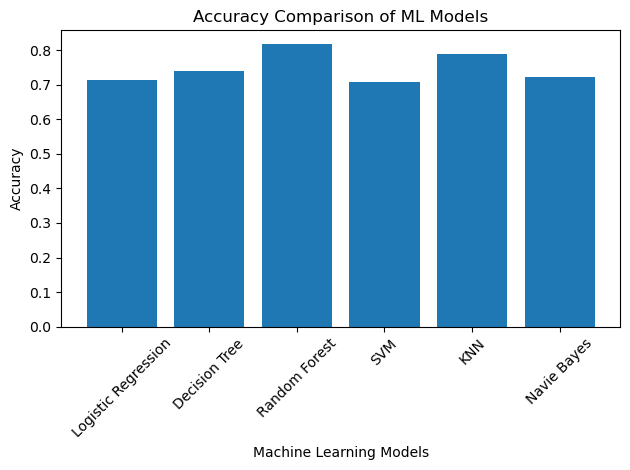

In [88]:
plt.figure()
plt.bar(result_df['Model'],result_df['Accuracy'])
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of ML Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

MANY MORE MODELS


==== Logistic Regression ====
Accuracy: 0.7123799359658485
Precision: 0.677536231884058
Recall: 0.80343716433942
F1-score: 0.7351351351351352

==== Decision Tree ====
Accuracy: 0.7382604055496265
Precision: 0.7276485788113695
Recall: 0.7561761546723953
F1-score: 0.741638135370029

==== Random Forest ====
Accuracy: 0.816435432230523
Precision: 0.7663339382940109
Recall: 0.9070891514500538
F1-score: 0.8307919331037875

==== Gradient Boosting ====
Accuracy: 0.7532017075773746
Precision: 0.6946406314914831
Recall: 0.8979591836734694
F1-score: 0.7833216209885219

==== SVM ====
Accuracy: 0.7091782283884739
Precision: 0.6580671580671581
Recall: 0.8630504833512352
F1-score: 0.7467472118959108

==== KNN ====
Accuracy: 0.78948772678762
Precision: 0.7264668636555509
Recall: 0.9242749731471536
F1-score: 0.8135192625856772

==== Navie Bayes ====
Accuracy: 0.721718249733191
Precision: 0.6699875466998755
Recall: 0.8668098818474759
F1-score: 0.755794895808944


c:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:12:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==== XGBoost ====
Accuracy: 0.8025613660618997
Precision: 0.7728599221789884
Recall: 0.8533834586466166
F1-score: 0.8111281265952016


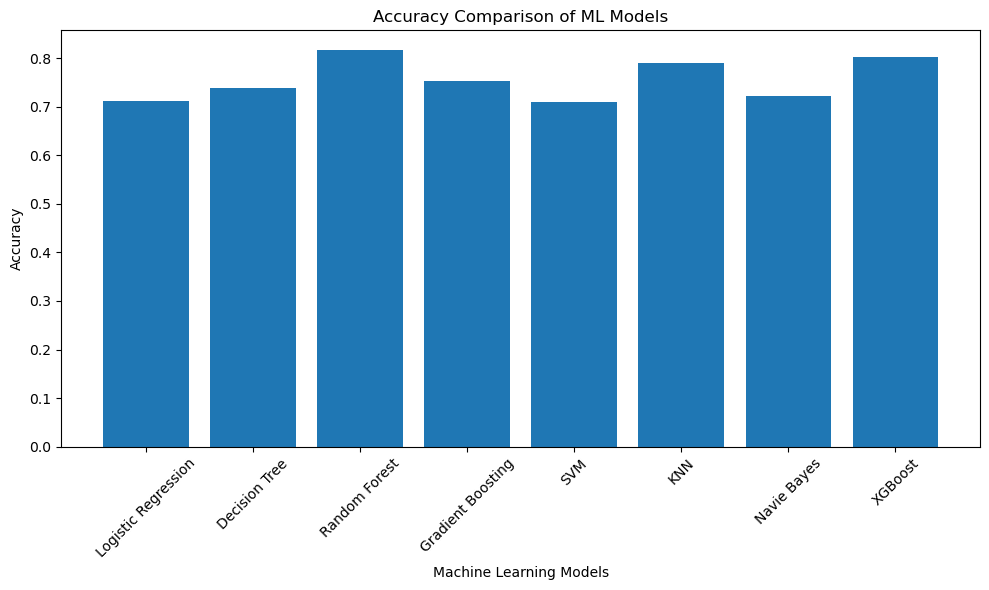

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

X = merged_df[['SWEAT index', 'K index', 'Totals totals index', 'Environmental_Stability',
               'Moisture_Indices', 'Convective_Potential', 'Temperature_Pressure',
               'Moisture_Temperature_Profiles']]
y = merged_df['TH']

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Navie Bayes': GaussianNB(), # Kept 'Navie' to match your setup
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results={}

for model_name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    results[model_name]=accuracy

    print(f"\n==== {model_name} ====")
    print("Accuracy:",accuracy)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1-score:",f1)

plt.figure(figsize=(10,6))
plt.bar(results.keys(),results.values())
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of ML Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## HYPERPARAMETER TUNING

In [90]:
from sklearn.model_selection import GridSearchCV

In [91]:
top3_models=result_df.sort_values(
    by='Accuracy',ascending=False
).head(3)

print("Top 3 Models Based on Accuracy:\n")
print(top3_models[['Model','Accuracy']])

Top 3 Models Based on Accuracy:

           Model  Accuracy
2  Random Forest  0.816435
4            KNN  0.789488
1  Decision Tree  0.738260


In [92]:
param_grids = {

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "Decision Tree": {
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear"]
    },

    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    }
}


In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tuned_result = []

# Loop runs dynamically over your top 3 chosen models
for model_name in top3_models['Model']:
    print("\n" + "=" * 60)
    print(f"Hyperparameter Tuning for {model_name}")

    # Extracts configuration smoothly
    model = models[model_name]
    param_grid = param_grids[model_name]

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    
    # Calculate basic classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Extract confusion matrix values safely
    total_positive = cm[1].sum()
    total_negative = cm[0].sum()
    true_positives = cm[1][1]
    false_positives = cm[0][1]
    false_negatives = cm[1][0]
    true_negatives = cm[0][0]

    # Core Verification Metrics
    pod = true_positives / total_positive if total_positive > 0 else 0
    
    # FIX: False Alarm Ratio (FAR) formula correction
    predicted_positives = true_positives + false_positives
    far = false_positives / predicted_positives if predicted_positives > 0 else 0

    # Critical Success Index (CSI)
    csi_denom = true_positives + false_positives + false_negatives
    csi = true_positives / csi_denom if csi_denom > 0 else 0

    # Heidke Skill Score (HSS)
    hss_num = 2 * ((true_positives * true_negatives) - (false_positives * false_negatives))
    hss_denom = ((true_positives + false_negatives) * (false_positives + true_negatives) +
                 (true_positives + false_positives) * (false_negatives + true_negatives))
    hss = hss_num / hss_denom if hss_denom > 0 else 0

    # Log results
    tuned_result.append([
        model_name, accuracy, precision, recall, f1,
        pod, far, hss, csi, grid.best_params_
    ])

    print("Best Parameters : ", grid.best_params_)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Probability of Detection (POD): {pod:.4f}")
    print(f"False Alarm Rate (FAR): {far:.4f}")
    print(f"Heidke Skill Score (HSS): {hss:.4f}")
    print(f"Critical Success Index (CSI): {csi:.4f}")



Hyperparameter Tuning for Random Forest
Best Parameters :  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.8215
Precision: 0.7688
Recall: 0.9162
F1-score: 0.8361
Probability of Detection (POD): 0.9162
False Alarm Rate (FAR): 0.2312
Heidke Skill Score (HSS): 0.6553
Critical Success Index (CSI): 0.7183

Hyperparameter Tuning for KNN
Best Parameters :  {'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.8164
Precision: 0.7481
Recall: 0.9506
F1-score: 0.8373
Probability of Detection (POD): 0.9506
False Alarm Rate (FAR): 0.2519
Heidke Skill Score (HSS): 0.6572
Critical Success Index (CSI): 0.7201

Hyperparameter Tuning for Decision Tree
Best Parameters :  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.7447
Precision: 0.7172
Recall: 0.8024
F1-score: 0.7574
Probability of Detection (POD): 0.8024
False Alarm Rate (FAR): 0.2828
Heidke Skill Score (HSS): 0.4931
Critical Success Index (CSI): 0.6095


In [94]:
tuned_result_df=pd.DataFrame(
    tuned_result,
    columns=[
        'Model','Accuracy','Precision','Recall','F1-Score',
        'POD','FAR','HSS','CSI','best Parameters'
    ]
)
print("\nFinal Tuned Model Comparison:\n")
print(tuned_result_df)


Final Tuned Model Comparison:

           Model  ...                                    best Parameters
0  Random Forest  ...  {'max_depth': None, 'min_samples_leaf': 1, 'mi...
1            KNN  ...          {'n_neighbors': 3, 'weights': 'distance'}
2  Decision Tree  ...  {'max_depth': 20, 'min_samples_leaf': 1, 'min_...

[3 rows x 10 columns]


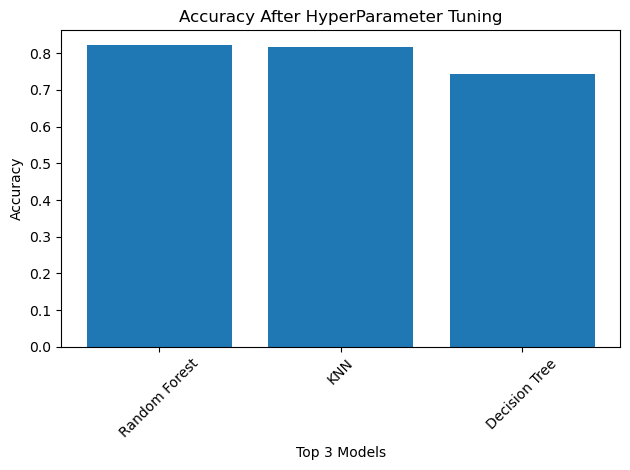

In [95]:
plt.figure()

plt.bar(tuned_result_df['Model'],tuned_result_df['Accuracy'])

plt.xlabel("Top 3 Models")
plt.ylabel("Accuracy")
plt.title("Accuracy After HyperParameter Tuning")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ML FLOW TRACKING

In [96]:
import mlflow
import mlflow.sklearn

In [97]:
report={
    'baseline_models':{},
    'tuned_models':{}
}

In [98]:
for model_name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)

    total_positive=cm[1].sum()
    total_negative=cm[0].sum()
    true_positives=cm[1][1]
    false_positives=cm[0][1]
    false_negatives=cm[1][0]
    true_negatives=cm[0][0]

    pod=true_positives/total_positive
    far=false_positives/total_negative

    hss=2 * ((true_positives * true_negatives) - (false_positives * false_negatives)) / (
        (true_positives + false_negatives) * (false_positives + true_negatives) +
        (true_positives + false_positives) * (false_negatives + true_negatives))
    csi=true_positives/(true_positives+false_positives+false_negatives)

    report['baseline_models'][model_name]={
        'metrics':{
            'accuracy':accuracy,
            'precision':precision,
            'recall':recall,
            'f1_score':f1,
            'pod':pod,
            'far':far,
            'hss':hss,
            'csi':csi
        }
    }

    

c:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:14:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [99]:
for model_name in top3_models['Model']:
    grid=GridSearchCV(
        estimator=models[model_name],
        param_grid=param_grids[model_name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(x_train,y_train)
    best_model=grid.best_estimator_

    y_pred=best_model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)

    total_positive=cm[1].sum()
    total_negative=cm[0].sum()
    true_positives=cm[1][1]
    false_positives=cm[0][1]
    false_negatives=cm[1][0]
    true_negatives=cm[0][0]

    pod=true_positives/total_positive
    far=false_positives/total_negative

    hss=2 * ((true_positives * true_negatives) - (false_positives * false_negatives)) / (
        (true_positives + false_negatives) * (false_positives + true_negatives) +
        (true_positives + false_positives) * (false_negatives + true_negatives))
    csi=true_positives/(true_positives+false_positives+false_negatives)

    report['tuned_models'][model_name]={
        'metrics':{
            'accuracy':accuracy,
            'precision':precision,
            'recall':recall,
            'f1_score':f1,
            'pod':pod,
            'far':far,
            'hss':hss,
            'csi':csi
        }
    }
    

In [100]:
import mlflow

# Force the script to send data directly to the server on port 5000
mlflow.set_tracking_uri("http://127.0.0.1:5000")


In [104]:
mlflow.set_experiment('Thunderstorm_Prediction_ML_V2')

2026/08/02 18:16:39 INFO mlflow.tracking.fluent: Experiment with name 'Thunderstorm_Prediction_ML_V2' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1785674799839, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1785674799839, lifecycle_stage='active', name='Thunderstorm_Prediction_ML_V2', tags={}, trace_location=None, workspace='default'>

In [105]:
for model_name,model_data in report['tuned_models'].items():
    with mlflow.start_run(run_name=model_name):
        for param , value in model_data.get('best_params',{}).items():
            mlflow.log_param(param,value)
        for metric,value in model_data.get('metrics',{}).items():
            mlflow.log_metric(metric,value)

        best_model=GridSearchCV(
            estimator=models[model_name],
            param_grid=param_grids[model_name],
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        ).fit(x_train,y_train).best_estimator_

        trusted_types = [
        'sklearn.metrics._dist_metrics.EuclideanDistance64', 
        'sklearn.neighbors._kd_tree.KDTree'
        ]
        
        mlflow.sklearn.log_model(
            best_model,
            artifact_path='model',
            skops_trusted_types=trusted_types
        )

2026/08/02 18:17:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/3/runs/ddbcf3faf3944dfaa1ccc3dce0f7c385
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/08/02 18:18:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run KNN at: http://127.0.0.1:5000/#/experiments/3/runs/acd12216989742c89c5f838b274d738f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/08/02 18:18:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Decision Tree at: http://127.0.0.1:5000/#/experiments/3/runs/bab5a9f324084689a423d8da7feddb36
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


STORING BEST MODEL

In [106]:
best_model_name=max(
    report['tuned_models'],
    key=lambda m : report['tuned_models'][m]['metrics']['accuracy']
)

In [108]:
# .get() returns an empty dict {} if 'best_params' is missing
best_params = report['tuned_models'][best_model_name].get('best_params', {})

# This works fine now; an empty dict means it uses standard defaults
best_model = models[best_model_name].set_params(**best_params)
best_model.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
import joblib

# Clear, correct f-string structure
filename = f"../model/{best_model_name.replace(' ', '_')}_best_model.pkl"

joblib.dump(best_model, filename)


['../model/Random_Forest_best_model.pkl']